# $\phi^4$ and $\phi^2$ Hamiltonian Truncation on a Circle

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + \frac{m_V^2}{2} H_2$$

$$H_\text{eff} = H_0 + \frac{g}{24}H_4$$

and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

NOTE This code uses DIFFERENT NOTATION as it is based on the code snippet from arXiv:2110.08273.


Reference: arXiv:2110.08273


In [1]:
import math
import bisect
import numpy as np
import scipy.sparse.linalg as sp_linalg
from scipy.sparse import csr_matrix, identity
import matplotlib.pyplot as plt
import csv
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
%matplotlib inline


## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as lists `[n₀, n₁₊, n₁₋, n₂₊, n₂₋, …]` where the helper `ix(l,σ)` gives the list index.


In [2]:
omega_list = []   # omega_list[l] = sqrt(l²/r² + m²)

def omega(l, m, r):
    """State Frequency"""
    return math.sqrt(float(l)*float(l)/(r*r) + m*m)

def gen_omega_list(lmax, m, r):
    global omega_list
    omega_list = [omega(l, m, r) for l in range(lmax + 1)]

def ix(l, sigma):
    """State-list index for mode (l, sigma)."""
    if l == 0: return 0
    return 2*l - 1 if sigma >= 0 else 2*l

def the_l(i):
    """Mode number from state-list index."""
    if i == 0: return 0
    return int((i+1)/2) if i % 2 != 0 else int(i/2)

def the_sigma(i):
    if i == 0: return 0
    return 1 if i % 2 != 0 else -1


## 2. Basis generation

`gen_basis` recursively builds all occupation-number states with energy ≤ `e_max`.
We then filter to the **zero-total-momentum** sector (`l_total == 0`) and optionally
to the **even-parity** sector (even total particle number).


In [3]:
def gen_basis(lmax, e_max, m, r):
    if lmax == 0:
        return list(map(lambda x: [x], list(range(0, int(math.floor(e_max/m)) + 1))))
    result = []
    for n in range(0, int(math.floor(e_max/omega(lmax, m, r))) + 1):
        prev_list = gen_basis(lmax-1, e_max - n*omega(lmax, m, r), m, r)
        for NP in range(0, n+1):
            result += list(map(lambda x: list(x) + [NP, n-NP], prev_list))
    return result

def make_basis(lmax, e_max, m, r):
    """Generate full basis and set omega_list as a side-effect."""
    global omega_list
    basis = gen_basis(lmax, e_max, m, r)
    gen_omega_list(lmax, m, r)
    basis.sort()
    return basis

def count_particles(state):
    return sum(state)

def l_total(state):
    """Total momentum in units of 1/r."""
    l_sum = 0
    for i in range(1, len(state)):
        if i % 2 != 0:
            l_sum += state[i] * the_l(i)
        else:
            l_sum -= state[i] * the_l(i)
    return l_sum

def state_energy(state, m, r):
    total = 0
    for i in range(len(state)):
        total += state[i] * omega_list[abs(the_l(i))]
    return total

def basis_l0(basis):    return [s for s in basis if l_total(s) == 0]
def basis_even(basis):  return [s for s in basis if sum(s) % 2 == 0]
def basis_odd(basis):   return [s for s in basis if sum(s) % 2 != 0]


def effective_lmax(lmax, e_max, m, r):
    """Modes above this cannot appear in zero-momentum states at energy e_max."""
    
    '''Note this equation is https://arxiv.org/pdf/2110.08273 Eq. (5.5), and maybe the relevant discussion of the 'quantisation mass' on Pg. (40) 
    of this paper and Eq. (B.3) of https://arxiv.org/pdf/2507.15941. However, note for future self: I am a little confused by the factors here.'''

    if m**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - m**2))))))
    return 0



## 3. Hamiltonian operators

Each function below builds a sparse matrix for a specific combination of raising ($a^\dagger$) and lowering ($a$) operators acting on the basis.

- `lower4` — annihilate 4 particles (contributes to $\delta H_4$)
- `raise1low3` — annihilate 3, create 1
- `raise2low2` — annihilate 2, create 2 (diagonal-block term)
- `lower2` — annihilate 2 particles (contributes to $\delta H_2$)
- `raise1low1` — annihilate 1, create 1 (diagonal term of $\delta H_2$)

The op-list functions enumerate all momentum-conserving mode combinations with the
correct symmetry factor, following arXiv:2507.15941 Eqs. (2.5)–(2.7).


In [4]:
def lower4(l1,s1,l2,s2,l3,s3,l4,s4, e_max,m,r,basis):
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                norm *= math.sqrt(ns2[ix(l3,s3)])
                if norm != 0:
                    ns3 = [ns2[ix(l3,s3)]-1 if i==ix(l3,s3) else ns2[i] for i in range(ix_max)]
                    norm *= math.sqrt(ns3[ix(l4,s4)])
                    if norm != 0:
                        ns4 = [ns3[ix(l4,s4)]-1 if i==ix(l4,s4) else ns3[i] for i in range(ix_max)]
                        if state_energy(ns4,m,r) <= e_max:
                            pos = bisect.bisect_left(basis, ns4)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise1low3(l1,s1,l2,s2,l3,s3,l4,s4, e_max,m,r,basis):
    # l4,s4 is the raising operator
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                norm *= math.sqrt(ns2[ix(l3,s3)])
                if norm != 0:
                    ns3 = [ns2[ix(l3,s3)]-1 if i==ix(l3,s3) else ns2[i] for i in range(ix_max)]
                    norm *= math.sqrt(ns3[ix(l4,s4)]+1)
                    if norm != 0:
                        ns4 = [ns3[ix(l4,s4)]+1 if i==ix(l4,s4) else ns3[i] for i in range(ix_max)]
                        if state_energy(ns4,m,r) <= e_max:
                            pos = bisect.bisect_left(basis, ns4)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise2low2(l1,s1,l2,s2,l3,s3,l4,s4, e_max,m,r,basis):
    # l3,s3 and l4,s4 are raising
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        state = basis[state_index]
        pos = -1
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                norm *= math.sqrt(ns2[ix(l3,s3)]+1)
                if norm != 0:
                    ns3 = [ns2[ix(l3,s3)]+1 if i==ix(l3,s3) else ns2[i] for i in range(ix_max)]
                    norm *= math.sqrt(ns3[ix(l4,s4)]+1)
                    if norm != 0:
                        ns4 = [ns3[ix(l4,s4)]+1 if i==ix(l4,s4) else ns3[i] for i in range(ix_max)]
                        if ns4 == state:
                            pos = state_index
                        elif state_energy(ns4,m,r) <= e_max:
                            pos = bisect.bisect_left(basis, ns4)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))


def lower2(l1,s1,l2,s2, e_max,m,r,basis):
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)])
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]-1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                if state_energy(ns2,m,r) <= e_max:
                    pos = bisect.bisect_left(basis, ns2)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

def raise1low1(l1,s1,l2,s2, e_max,m,r,basis):
    row,col,data = [],[],[]
    ix_max = len(basis[0])
    for state_index in range(len(basis)):
        pos = -1
        state = basis[state_index]
        norm = math.sqrt(state[ix(l1,s1)])
        if norm != 0:
            ns1 = [state[ix(l1,s1)]-1 if i==ix(l1,s1) else state[i] for i in range(ix_max)]
            norm *= math.sqrt(ns1[ix(l2,s2)]+1)
            if norm != 0:
                ns2 = [ns1[ix(l2,s2)]+1 if i==ix(l2,s2) else ns1[i] for i in range(ix_max)]
                if ns2 == state:
                    pos = state_index
                elif state_energy(ns2,m,r) <= e_max:
                    pos = bisect.bisect_left(basis, ns2)
        if pos != -1:
            row.append(state_index); col.append(pos); data.append(norm)
    return csr_matrix((data,(row,col)), shape=(len(basis),len(basis)))

In [5]:
# Each function returns a list of [momenta, symmetry_factor] pairs
# covering all momentum-conserving 4-mode combinations (with no double-counting).

def raise4_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for j in range(-lmax, lmax-2):
        for k in range(j+1, lmax-1):
            for l in range(k+1, lmax):
                n = -l-k-j
                if n in range(l+1,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)]+omega_list[abs(l)]+omega_list[abs(n)] <= e_max:
                    op_list.append([[j,k,l,n], 24])
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            if (-k-j)%2==0:
                l = int((-k-j)/2)
                if l in range(k+1,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)]+2*omega_list[abs(l)] <= e_max:
                    op_list.append([[j,k,l,l], 12])
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            l = -2*k-j
            if l in range(k+1,lmax+1) and omega_list[abs(j)]+2*omega_list[abs(k)]+omega_list[abs(l)] <= e_max:
                op_list.append([[j,k,k,l], 12])
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            l = -k-2*j
            if l in range(k+1,lmax+1) and 2*omega_list[abs(j)]+omega_list[abs(k)]+omega_list[abs(l)] <= e_max:
                op_list.append([[j,j,k,l], 12])
    for k in range(-lmax, lmax):
        l = -k
        if l in range(k+1,lmax+1) and 2*omega_list[abs(k)]+2*omega_list[abs(l)] <= e_max:
            op_list.append([[k,k,l,l], 6])
    for j in range(-lmax, lmax):
        if j%3==0:
            l = int(-j/3)
            if l in range(j+1,lmax+1) and omega_list[abs(j)]+3*omega_list[abs(l)] <= e_max:
                op_list.append([[j,l,l,l], 4])
    for j in range(-lmax, lmax):
        k = -3*j
        if k in range(j+1,lmax+1) and 3*omega_list[abs(j)]+omega_list[abs(k)] <= e_max:
            op_list.append([[j,j,j,k], 4])
    op_list.append([[0,0,0,0], 1])
    return op_list

def raise31_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for j in range(-lmax, lmax-1):
        for k in range(j+1, lmax):
            for l in range(k+1, lmax+1):
                n = l+k+j
                if n in range(-lmax,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)]+omega_list[abs(l)] <= e_max and omega_list[abs(n)] <= e_max:
                    op_list.append([[j,k,l,n], 6])
    for j in range(-lmax, lmax):
        for k in range(j+1, lmax+1):
            n = j+2*k
            if n in range(-lmax,lmax+1) and omega_list[abs(j)]+2*omega_list[abs(k)] <= e_max and omega_list[abs(n)] <= e_max:
                op_list.append([[j,k,k,n], 3])
    for k in range(-lmax, lmax):
        for l in range(k+1, lmax+1):
            n = 2*k+l
            if n in range(-lmax,lmax+1) and 2*omega_list[abs(k)]+omega_list[abs(l)] <= e_max and omega_list[abs(n)] <= e_max:
                op_list.append([[k,k,l,n], 3])
    for k in range(math.ceil(-lmax/3), math.floor(lmax/3)+1):
        n = 3*k
        if n in range(-lmax,lmax+1) and 3*omega_list[abs(k)] <= e_max and omega_list[abs(n)] <= e_max:
            op_list.append([[k,k,k,n], 1])
    return op_list

def raise22_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for j in range(-lmax, lmax):
        for k in range(j+1, lmax+1):
            for l in range(-lmax, lmax):
                n = -l+k+j
                if n in range(l+1,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)] <= e_max and omega_list[abs(l)]+omega_list[abs(n)] <= e_max:
                    op_list.append([[j,k,l,n], 4])
    for j in range(-lmax, lmax):
        for k in range(j+1, lmax+1):
            if (k+j)%2==0:
                l = int((k+j)/2)
                if l in range(-lmax,lmax+1) and omega_list[abs(j)]+omega_list[abs(k)] <= e_max and 2*omega_list[abs(l)] <= e_max:
                    op_list.append([[j,k,l,l], 2])
    for l in range(-lmax, lmax):
        for n in range(l+1, lmax+1):
            if (l+n)%2==0:
                k = int((l+n)/2)
                if k in range(-lmax,lmax+1) and 2*omega_list[abs(k)] <= e_max and omega_list[abs(l)]+omega_list[abs(n)] <= e_max:
                    op_list.append([[k,k,l,n], 2])
    for k in range(-lmax, lmax+1):
        if 2*omega_list[abs(k)] <= e_max:
            op_list.append([[k,k,k,k], 1])
    return op_list

def raise2_op_list(lmax, e_max, m, r):
    global omega_list
    op_list = []
    for i in range(-lmax, 0):
        if 2*omega_list[abs(i)] <= e_max:
            op_list.append([[i,-i], 2])
    op_list.append([[0,0], 1])
    return op_list

def raise11_op_list(lmax):
    return [[[i,i], 1] for i in range(-lmax, lmax+1)]

## 4. Assembling H₀, H₂, H₄

**H₀** (arXiv:2507.15941 Eq. 2.4): diagonal free-field energy.

**H₄** (Eq. 2.5): the φ⁴ four-point interaction, assembled from all raising/lowering combinations.

**H₂** (Eq. 2.7): the φ² two-point interaction.


In [6]:
def h0(lmax, e_max, m, r, basis):
    n = len(basis)
    data = [state_energy(basis[i], m, r) for i in range(n)]
    return csr_matrix((data, (range(n), range(n))), shape=(n,n))

def term_4low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis=len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise4_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        l = op[0][2]
        k = op[0][3]
        new_op = lower4(int(abs(k)), np.sign(k), int(abs(l)), np.sign(l), int(abs(j)), np.sign(j), int(abs(i)), np.sign(i), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = op[1]/math.sqrt(omega_list[abs(i)] * omega_list[abs(j)] * omega_list[abs(l)] * omega_list[abs(k)])
            total_op = total_op+factor*new_op
    return total_op

def term_1raise3low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis = len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise31_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        l = op[0][2]
        # k is the raising operator
        k = op[0][3]
        new_op = raise1low3(int(abs(i)), np.sign(i), int(abs(j)), np.sign(j), int(abs(l)), np.sign(l), int(abs(k)), np.sign(k), e_max, m, r, basis)
        
        if new_op.count_nonzero() != 0:
            factor = 4 * op[1] / math.sqrt(omega_list[abs(i)] * omega_list[abs(j)] * omega_list[abs(l)] * omega_list[abs(k)])
            total_op = total_op + factor * new_op
    return total_op

def term_2raise2low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis=len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise22_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        l = op[0][2]
        k = op[0][3]
        new_op = raise2low2(abs(k), np.sign(k), abs(l), np.sign(l), abs(j), np.sign(j), abs(i), np.sign(i), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = 6 * op[1] / math.sqrt(omega_list[abs(i)] * omega_list[abs(j)] * omega_list[abs(l)] * omega_list[abs(k)])            
            total_op = total_op + factor * new_op
    return total_op


def term_2low(lmax, e_max, m, r, basis):
    global omega_list
    length_basis = len(basis)
    total_op = csr_matrix(([], ([], [])), shape=(length_basis, length_basis))
    op_list = raise2_op_list(lmax, e_max, m, r)
    for op in op_list:
        i = op[0][0]
        j = op[0][1]
        new_op = lower2(abs(j), np.sign(j), abs(i), np.sign(i), e_max, m, r, basis)
        if new_op.count_nonzero() != 0:
            factor = op[1]/math.sqrt(omega_list[abs(i)] * omega_list[abs(j)])
            total_op = total_op+factor*new_op
    return total_op


def term_1raise1low(lmax, e_max, m, r, basis):
    global omega_list
    row = []
    col = []
    data = []
    length_basis=len(basis)
    for state_index in range(length_basis):
        state = basis[state_index]
        row.append(state_index)
        col.append(state_index)
        factor = 0
        for i in range(len(state)):
            factor = factor + 2 * state[i] / omega_list[abs(the_l(i))]
        data.append(factor)
    return csr_matrix((data, (row, col)), shape=(length_basis, length_basis))


def delta_h4(lmax, e_max, m, r, basis):
    t4 = term_4low(lmax, e_max, m, r, basis)
    t3 = term_1raise3low(lmax, e_max, m, r, basis)
    return t4 + t4.T + term_2raise2low(lmax, e_max, m, r, basis) + t3 + t3.T


   
def delta_h2(lmax, e_max, m, r, basis): 
    t2 = term_2low(lmax, e_max, m, r, basis)
    return t2 + t2.T + term_1raise1low(lmax, e_max, m, r, basis)


## 5. Diagonalization

For small matrices we use dense `eigvalsh`. For large ones we use a sparse shift-invert trick to find the `k` lowest eigenvalues without forming the dense matrix.

In [7]:
def compute_eigenvalues(H, k):
    """Return the k lowest eigenvalues of sparse symmetric H."""
    n = H.shape[0]
    k = min(k, n)
    if k > n - 2:
        return sorted(np.linalg.eigvalsh(H.toarray()))[:k]
    # Shift by the matrix norm so eigs(..., which='LM') finds the most-negative eigenvalues of H
    norm = sp_linalg.norm(H)
    eigs = sp_linalg.eigs(H - norm*identity(n), k, which='LM')[0]
    return sorted((eigs.real + norm).tolist())


## 6. Basis Generation Timer

E_max: 10
1.71 ms ± 12.6 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 11
3.71 ms ± 20.8 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 12
5.88 ms ± 32.8 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 13
11.9 ms ± 168 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 14
18.4 ms ± 54.1 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 15
34.7 ms ± 194 μs per loop (mean ± std. dev. of 4 runs, 10 loops each)
E_max: 16
53 ms ± 143 μs per loop (mean ± std. dev. of 4 runs, 10 loops each)
E_max: 17
96.8 ms ± 2.08 ms per loop (mean ± std. dev. of 4 runs, 10 loops each)
E_max: 18
145 ms ± 1.57 ms per loop (mean ± std. dev. of 4 runs, 10 loops each)
E_max: 19
246 ms ± 5.67 ms per loop (mean ± std. dev. of 4 runs, 1 loop each)


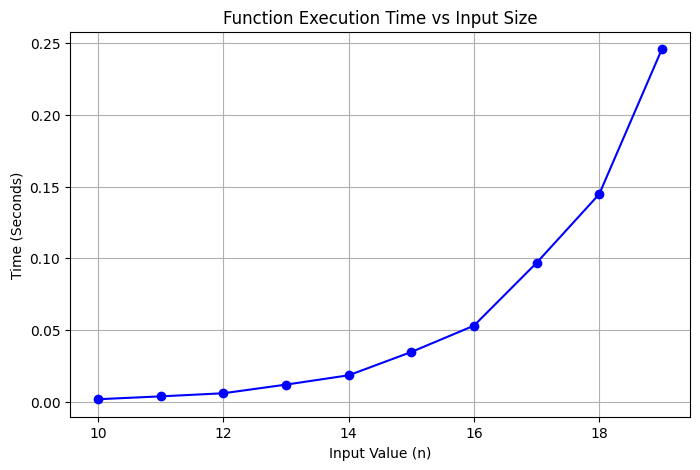

In [8]:
# Hamiltonian Parameters
mQ = 1.; r = 1.
emax_list = range(10,40)
#List Construction.
execution_times = []; basis_lengths = []

for e_max in emax_list:
    print(f"E_max: {e_max}")
    lmaxeff = effective_lmax(e_max,e_max,mQ,r)
    
    duration = %timeit -o -r4 basis_l0(make_basis(lmaxeff,e_max,mQ,r))  # Execute the basis generation function.
    basis = make_basis(lmaxeff,e_max,mQ,r)

    # Add to result.
    execution_times.append(duration.average)
    basis_lengths.append(len(basis))
    
# Export results to a CSV file
csv_filename = "benchmark_basisgen_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, r = {r}")
    writer.writerow("EMax List")
    writer.writerow(emax_list)
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='b')
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.grid(True)
plt.show()

## 6. Quick example

Build $H_\text{eff} = H_0 + \frac{g}{24} H_4$ for a single `E_max` and print the lowest 10 eigenvalues.

In [9]:
# Hamiltonian Parameters
mQ, r, g = 1.0, 1.0, 4*math.pi
e_max = 5

# Builds the basis.
lmaxeff = effective_lmax(e_max, e_max, mQ, r)
gen_omega_list(lmaxeff, mQ, r)
basis = basis_l0(make_basis(lmaxeff, e_max, mQ, r))
basis.sort()

print(f'e_max={e_max}, lmaxeff={lmaxeff}, basis size={len(basis)}')

e_max=5, lmaxeff=2, basis size=10


In [10]:
# Building the Transition Amplitude
H0   = h0(lmaxeff, e_max, mQ, r, basis)
H2   = delta_h2(lmaxeff, e_max, mQ, r, basis)
H4   = (1/r)*(1/(8*math.pi)) * delta_h4(lmaxeff, e_max, mQ, r, basis)

H_raw = H0 + (g/24)*H4

eigs_raw = compute_eigenvalues(H_raw, 10)

print('Lowest 10 Raw eigenvalues:', [f'{e:.4f}' for e in eigs_raw])
print(f'Raw gap E1-E0:        {eigs_raw[1]-eigs_raw[0]:.6f}')


Lowest 10 Raw eigenvalues: ['-0.0110', '0.9533', '2.0343', '3.0168', '3.3231', '4.5981', '4.9344', '5.2845', '7.2206', '7.8247']
Raw gap E1-E0:        0.964308


### Now Look at basis occupancy plots:

In [11]:
# Benchmark Hamiltonian Parameters.
mQ, r, g = 1.0, 1.0, 4*np.pi
e_max = 7


lmaxeff = effective_lmax(e_max, e_max, mQ, r)
gen_omega_list(lmaxeff, mQ, r)
basis = basis_l0(make_basis(lmaxeff, e_max, mQ, r))


basis.sort()
print(f'e_max={e_max}, lmaxeff={lmaxeff}, basis size={len(basis)}')

e_max=7, lmaxeff=3, basis size=25


In [12]:
#Re-orders the states from angular momenta as (0, +1, -1, +2, -2, ...) to (..., -2, -1, 0, +1, +2, ...)
def sort_modes(state, lmaxeff):
    sorted_state = []
    # Iterate linearly from -lmaxeff to +lmaxeff
    for new_index in range(-lmaxeff, lmaxeff + 1):            
        original_index=(ix(abs(new_index),np.sign(new_index)))
            
        if original_index<len(state):
            sorted_state.append(state[original_index])
        else: sorted_state.append(0)

    return sorted_state

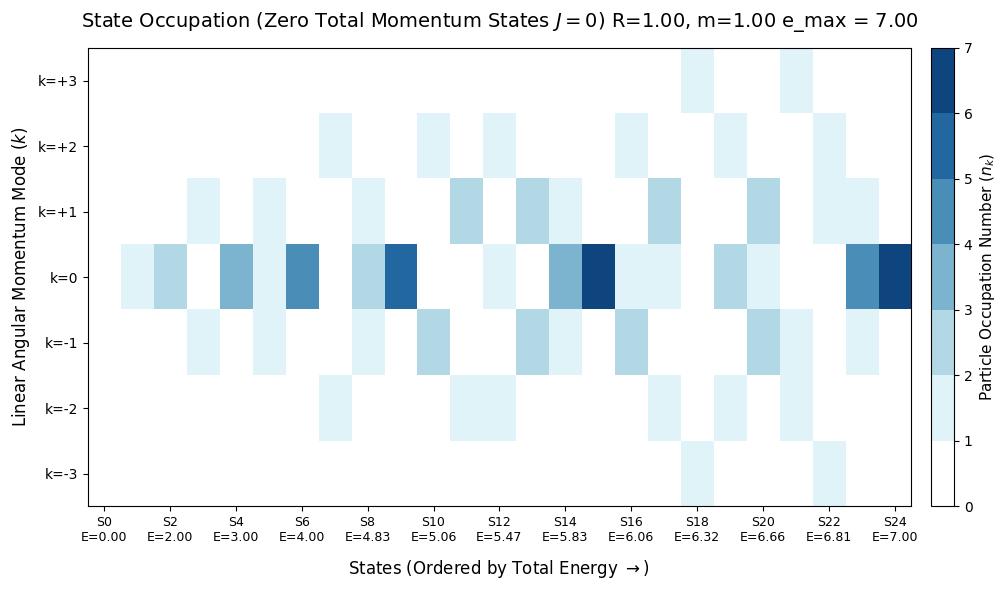

In [13]:
from matplotlib.colors import ListedColormap
# -- Mode Range and J=0 Basis for Plot ---
lrange = lmaxeff 
_basis = basis

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))


# --- Sort states by physical free energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
state_energies = []
for state in _basis:
    sorted_states.append(sort_modes(state, lrange))
    state_energies.append(state_energy(state,mQ,r))
    
sorted_states=[x for x, _ in sorted(zip(sorted_states, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Linear Grid Matrix ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, item in enumerate(sorted_states):
    grid_matrix[:, col_idx] = item

# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes]
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)


# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    # Reducing the number of state labels if it becomes too large, as unreadable.
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]
    ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
    ax.set_xticklabels(_state_labels, fontsize=9)

else:
    ax.set_xticks(np.arange(0,len(sorted_states)))
    ax.set_xticklabels(state_labels, fontsize=9)
    
ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={mQ:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

### And the transition matrix plot for comparison.

2D $\phi^2$ Even Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R=1.0, m=1.0 e_max = 7:
2D $\phi^2$ Odd Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R=1.0, mQ=1.0 e_max = 7:


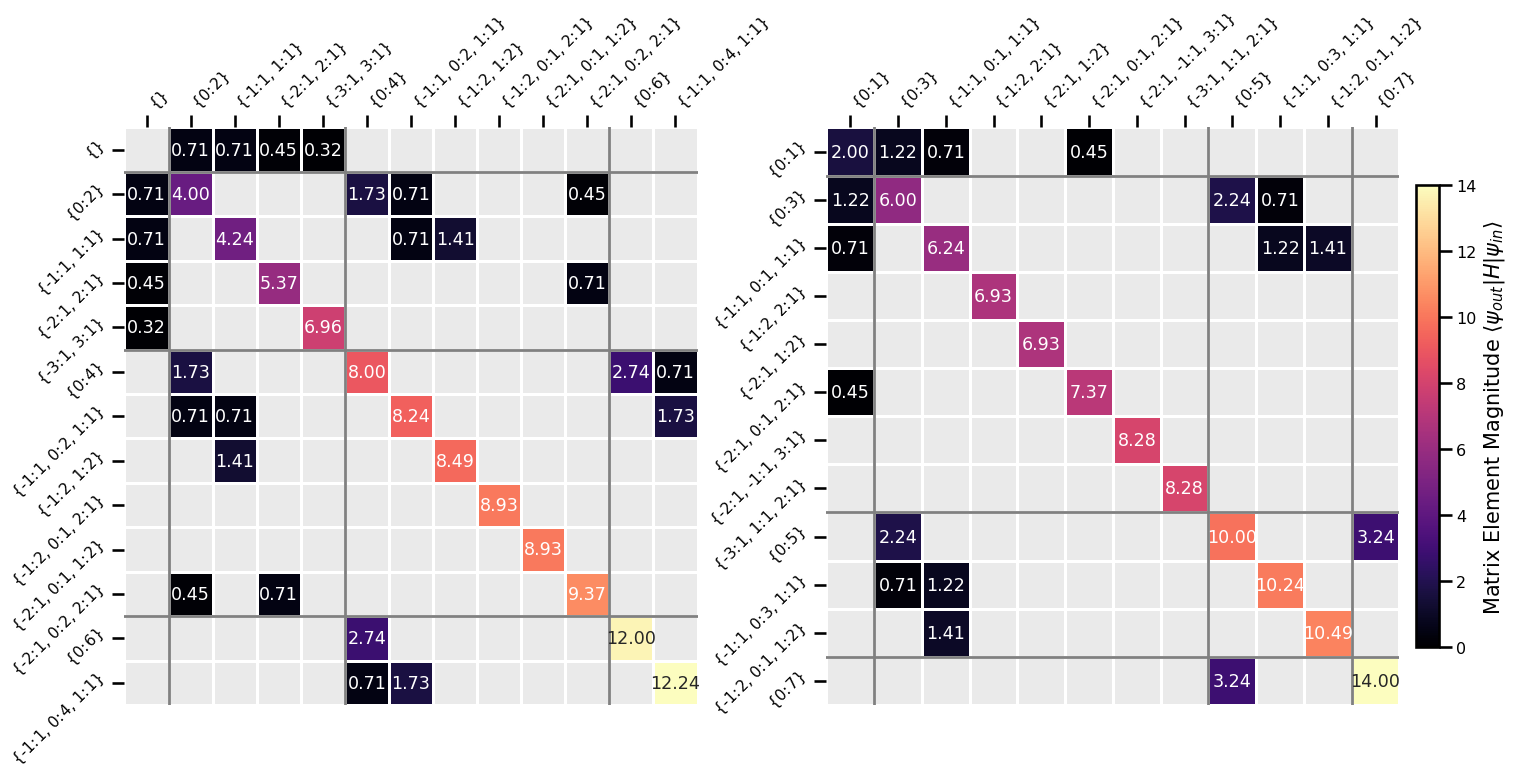

In [37]:
import seaborn as sns

# ---------------------------------------------------------
#               PREPARE THE PLOT
# ---------------------------------------------------------

# Benchmark Hamiltonian Parameters.
mQ, r = 1.0, 1.0
mV, g = 1.0, 4*np.pi
e_max = 7
phi2 = True # phi2 or phi4?


# -- Mode Range and J=0 Basis for Plot ---
lmaxeff = effective_lmax(e_max, e_max, mQ, r)
gen_omega_list(lmaxeff, mQ, r)
basis = basis_l0(make_basis(lmaxeff, e_max, mQ, r))

lrange = lmaxeff 
_basis_even = basis_even(basis)
_basis_odd = basis_odd(basis)

#Possible Angular Momenta
modes = list(range(-lrange, lrange+1))


# ---------------------------------------------------------
#               EVEN STATES
# ---------------------------------------------------------



# --- Generate Raw Hamiltonian Matrix (H_0 + V) --- 
if phi2: H_total_even =  h0(lmaxeff,e_max,mQ,r,_basis_even) + (mV**2)/2 * delta_h2(lmaxeff, e_max,mQ,r,_basis_even)
else: H_total_even = h0(lmaxeff,e_max,mQ,r,_basis_even) + (g/24)*(1/r)*(1/(8*math.pi))*delta_h4(lmaxeff,e_max,mQ,r,_basis_even)


# ---  Sort the basis using lexsort, primarily by occupation number, secondly by energy. ---
state_energies_even = [state_energy(state,mQ,r) for state in _basis_even]
occupation_numbers_even = [sum(state) for state in _basis_even]
sorted_indices_even = np.lexsort((state_energies_even, occupation_numbers_even)) 

sorted_states_even=np.array([sort_modes(state,lmaxeff) for state in _basis_even])[sorted_indices_even]
sorted_energies = np.array(state_energies_even)[sorted_indices_even]
H_sorted_even = H_total_even[sorted_indices_even, :][:, sorted_indices_even]


# --- State labels ---
verbose_labels_even = []

for state in sorted_states_even:
    occ_vector_even = {k:state[i] for i,k in enumerate(modes)}
    verbose_labels_even.append("{"+", ".join(f"{key}:\u200A{value}" for key, value in occ_vector_even.items() if value !=0)+"}")

# --- Boundaries between occupation numbers for the plot ---
boundaries_even = np.where(np.diff(np.sort(np.sum(sorted_states_even, axis=1))))[0] # List of places where state occupation number changes.
boundaries_even[0] = 0 # Fixing the zero entry.


# ---------------------------------------------------------
#               ODD STATES
# ---------------------------------------------------------


# --- Generate Raw Hamiltonian Matrix (H_0 + V) --- 
if phi2: H_total_odd =  h0(lmaxeff,e_max,mQ,r,_basis_odd) + (mV**2)/2 * delta_h2(lmaxeff, e_max,mQ,r,_basis_odd)
else: H_total_odd = h0(lmaxeff,e_max,mQ,r,_basis_odd) + (g/24)*(1/r)*(1/(8*math.pi))*delta_h4(lmaxeff,e_max,mQ,r,_basis_odd)


# ---  Sort the basis using lexsort, primarily by occupation number, secondly by energy. ---
state_energies_odd = [state_energy(state,mQ,r) for state in _basis_odd]
occupation_numbers_odd = [sum(state) for state in _basis_odd]
sorted_indices_odd = np.lexsort((state_energies_odd, occupation_numbers_odd)) 

sorted_states_odd=np.array([sort_modes(state,lmaxeff) for state in _basis_odd])[sorted_indices_odd]
sorted_energies_odd = np.array(state_energies_odd)[sorted_indices_odd]
H_sorted_odd = H_total_odd[sorted_indices_odd, :][:, sorted_indices_odd]


# --- State labels ---
verbose_labels_odd = []

for state in sorted_states_odd:
    occ_vector_odd = {k:state[i] for i,k in enumerate(modes)}
    verbose_labels_odd.append("{"+", ".join(f"{key}:\u200A{value}" for key, value in occ_vector_odd.items() if value !=0)+"}")

# --- Boundaries between occupation numbers for the plot ---
boundaries_odd = np.where(np.diff(np.sort(np.sum(sorted_states_odd, axis=1))))[0] # List of places where state occupation number changes.
boundaries_odd[0] = 0 # Fixing the zero entry.




# ---------------------------------------------------------
#               HEATMAPS
# ---------------------------------------------------------


# Use the same colour scale for both plots
vmin = min(H_sorted_even.min(), H_sorted_odd.min())
vmax = max(H_sorted_even.max(), H_sorted_odd.max())
norm = Normalize(vmin=vmin, vmax=vmax)


fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))


sns.set_context("talk", font_scale=0.7)

# --- Plotting the EVEN Heatmap Matrix ---
zero_mask = (H_sorted_even.toarray() == 0.0)
ax = sns.heatmap(
    H_sorted_even.toarray(), 
    ax=axes[0],
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels_even, 
    yticklabels=verbose_labels_even,
    mask=zero_mask,
    cbar=False
)

axes[0].xaxis.tick_top()
axes[0].xaxis.set_label_position('top')
axes[0].set_facecolor('#eaeaea') # Soft gray for zero elements

# Drawing separation dividers between states of differing occupation number.
for b in boundaries_even:
    axes[0].axvline(x=b+1, linewidth=2, color="grey")
    axes[0].axhline(y=b+1, linewidth=2, color="grey")

if phi2: print(rf"2D $\phi^2$ Even Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={mQ} e_max = {e_max}:")
else: print(rf"2D $\phi^4$ Even Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, m={mQ} e_max = {e_max}:")



# --- Plotting the ODD Heatmap Matrix ---


zero_mask = (H_sorted_odd.toarray() == 0.0)
ax = sns.heatmap(
    H_sorted_odd.toarray(), 
    ax=axes[1],
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels_odd, 
    yticklabels=verbose_labels_odd,
    mask=zero_mask,
    cbar=False
)
import matplotlib.transforms as transforms

axes[1].xaxis.tick_top()
axes[1].xaxis.set_label_position('top')
axes[1].set_facecolor('#eaeaea') # Soft gray for zero elements

for ax in axes:
    ax.tick_params(axis='x', labelrotation=45, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    


    for label in ax.get_xticklabels():
        label.set_ha('left')
        
    for label in ax.get_yticklabels():
        label.set_rotation(45)
        label.set_va('top')
        label.set_transform(
        label.get_transform() +
        transforms.ScaledTranslation(0, 10/72, ax.figure.dpi_scale_trans)
    )


# Drawing separation dividers between states of differing occupation number.
for b in boundaries_odd:
    axes[1].axvline(x=b+1, linewidth=2, color="grey")
    axes[1].axhline(y=b+1, linewidth=2, color="grey")
    
# Create a single shared colourbar
sm = ScalarMappable(norm=norm, cmap="magma")
sm.set_array([])  # Needed for older matplotlib versions

cbar = fig.colorbar(sm, ax=axes, shrink=0.8, pad=0.8,fraction=0.02)
cbar.set_label("Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$", fontsize=15)

fig.subplots_adjust(right=0.875)
fig.subplots_adjust(wspace=0.225)

if phi2: print(rf"2D $\phi^2$ Odd Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, mQ={mQ} e_max = {e_max}:")
else: print(rf"2D $\phi^4$ Odd Raw Hamiltonian Matrix Heatmap with Occupation Tracking, R={r}, mQ={mQ} e_max = {e_max}:")

if phi2: plt.savefig('phi2_transitionmatrix.pdf', format = 'pdf', bbox_inches="tight", pad_inches=0.1)
else: plt.savefig('phi4_transitionmatrix.pdf', format = 'pdf', bbox_inches="tight", pad_inches=0.1)

## 7. Matrix Element Generation Timer
This is to produce a .csv file for comparison with our new code. "phi2_benchmark_results.csv" and "phi4_benchmark_results.csv"

### $\phi^2$:

E_max: 10
798 μs ± 7.7 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 11
1.16 ms ± 7.18 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 12
1.48 ms ± 17.5 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 13
2.38 ms ± 148 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 14
3.07 ms ± 61.7 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 15
5 ms ± 149 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 16
7 ms ± 185 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 17
11.6 ms ± 621 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 18
15.5 ms ± 130 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 19
24.7 ms ± 1.24 ms per loop (mean ± std. dev. of 4 runs, 10 loops each)


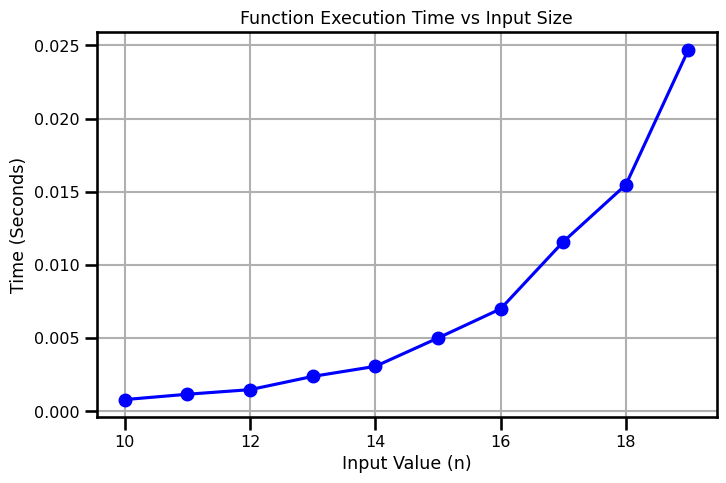

In [16]:
mQ = 1.; mV = 1.; r = 1. # Hamiltonian parameters.
execution_times = []; basis_lengths = []

# Test list.
emax_list = range(10,40)

for e_max in emax_list:
    print(f"E_max: {e_max}")
    
    # Prepare the basis in advance of timing.
    lmaxeff = effective_lmax(e_max,e_max,mQ,r)
    basis = basis_even(basis_l0(make_basis(lmaxeff,e_max,mQ,r)))
    
    # --- Generate Raw Hamiltonian Matrix (H_0 + V) --- 
    duration = %timeit -o -r4 (h0(lmaxeff,e_max,mQ,r,basis) + (mV**2/2)*delta_h2(lmaxeff,e_max,mQ,r,basis))

    # Store results.
    execution_times.append(duration.average)
    basis_lengths.append(len(basis))
    

# 3. Export results to a CSV file
csv_filename = "phi2_benchmark_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    # Writes Hamiltonian parameters for check.
    writer.writerow(f"mQ = {mQ}, mV = {mV}, r = {r}")
    # Writes emax list as header.
    writer.writerow("EMax List")  
    # Writes emax list.
    writer.writerow(emax_list)
    # Finally writes result header and results.
    writer.writerow(["Input Value", "Execution Time (Seconds)"]) 
    writer.writerows(zip(emax_list,execution_times))


# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='b')
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.grid(True)
plt.show()

### $\phi^4$

E_max: 10
23.6 ms ± 265 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
E_max: 11
46.8 ms ± 764 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
E_max: 12
67.6 ms ± 3.26 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
E_max: 13
133 ms ± 1.99 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
E_max: 14
192 ms ± 2.48 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
E_max: 15
381 ms ± 2.84 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
E_max: 16
563 ms ± 7.76 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
E_max: 17
1.11 s ± 12.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
E_max: 18
1.62 s ± 12.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
E_max: 19
3.06 s ± 37.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


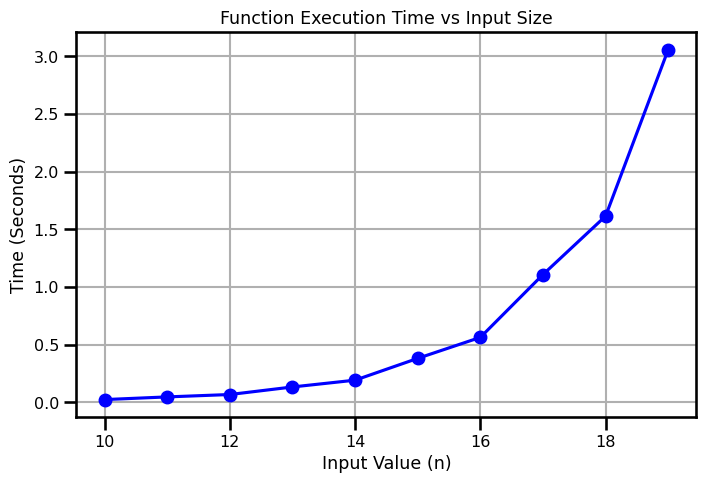

In [17]:
mQ = 1.; r = 1.; g = 4*np.pi # Hamiltonian parameters.
execution_times = []; basis_lengths = []

# Test list.
emax_list = range(10,40)

for e_max in emax_list:
    print(f"E_max: {e_max}")
    
    # Prepare the basis in advance of timing.
    lmaxeff = effective_lmax(e_max,e_max,mQ,r)
    basis = basis_even(basis_l0(make_basis(lmaxeff,e_max,mQ,r)))
    
    # --- Generate Raw Hamiltonian Matrix (H_0 + V) --- 

    duration = %timeit -o h0(lmaxeff,e_max,mQ,r,basis) + (g/24)*(1/r)*(1/(8*math.pi))*delta_h4(lmaxeff,e_max,mQ,r,basis)

    # Store results.
    execution_times.append(duration.average)
    basis_lengths.append(len(basis))
    

# 3. Export results to a CSV file
csv_filename = "phi4_benchmark_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    # Writes Hamiltonian parameters for check.
    writer.writerow(f"mQ = {mQ}, g = {g}, r = {r}")
    # Writes emax list as header.
    writer.writerow("EMax List")  
    # Writes emax list.
    writer.writerow(emax_list)
    # Finally writes result header and results.
    writer.writerow(["Input Value", "Execution Time (Seconds)"]) 
    writer.writerows(zip(emax_list,execution_times))

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='b')
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.grid(True)
plt.show()